# E4 — Coupled $\phi^4$ chain (24D)

**Target.** $q_i\in\mathbb R^2$, $N_s=12$ periodic sites, $\delta=1/N_s$, $\kappa=2.5$:
$$V(q) = \frac{\kappa}{2\delta}\sum_i\|q_{i+1}-q_i\|^2 + \delta\sum_i W(q_i),\qquad W(x,y) = (x^2-1)^2+(y^2-1)^2-0.05xy+0.03x+0.06y.$$
Four coherent phases $(\pm1,\pm1)$; for homogeneous fields $V(\mathbf 1\otimes v)=W(v)$, so the coherent barrier equals the barrier of $W$ ($\beta\cdot\min$ barrier $=7.14$), and the kink-pair cost $5.96\gg1$ makes **the coherent flip the minimum-energy path**. Init at the $--$ phase; partition = basin of $W$ at $\bar q = \tfrac1{N_s}\sum_i q_i$; references: harmonic (Laplace) mixture + a long PT chain (both labelled references, cross-checked).

In [1]:
EXPERIMENT = "coupled_phi4"
import os, sys, math, time, json
sys.path.insert(0, os.path.abspath(".."))
from src.gpu_guard import select_gpu
select_gpu(int(os.environ.get("JCP_GPU", "4")))
import torch
assert torch.cuda.device_count() == 1
torch.set_default_dtype(torch.float64)
import numpy as np
import pandas as pd

from src import config as C
from src.experiments import (build_e4, make_sampler_factory,
                             make_batched_factory, make_metrics)
from src.runner import (run_experiment_batched, run_one, refine_dt,
                        quadrature_refinement, write_timeseries_csv,
                        write_summary_csv, write_manifest,
                        ula_first_passage, hardware_manifest)
from src.samplers import tune_ladder
from src.certificate import make_phi_family, certificate_grid, certificate_importance
from src.plotting import metric_grid

DEV = "cuda"
RESULTS = os.path.abspath(os.path.join("..", "results", EXPERIMENT))
FIGURES = os.path.abspath(os.path.join("..", "figures", EXPERIMENT))
os.makedirs(RESULTS, exist_ok=True); os.makedirs(FIGURES, exist_ok=True)
exp = build_e4(device=DEV, basin_cache=os.path.join(RESULTS, "basin_map.npz"))
cfg = exp.cfg
print(f"experiment={cfg.name}  d={cfg.d}  N={cfg.n_particles}  T={cfg.T}  dt0={cfg.dt}")
print(f"beta={cfg.beta}  eps={cfg.eps}  lambda={cfg.lam}  seeds={cfg.seeds}")
print(hardware_manifest())

experiment=coupled_phi4  d=24  N=1000  T=100.0  dt0=0.002
beta=8.0  eps=0.125  lambda=1.0  seeds=(0, 1, 2, 3, 4)


{'cpu': 'AMD EPYC 9554 64-Core Processor', 'gpu': 'NVIDIA H200 NVL', 'torch': '2.13.0+cu130', 'cuda': '13.0', 'python': '3.12.13', 'git_sha': '389ecdd9aac0ed35b8e48b00d1cfdfdd534575a0', 'cuda_visible_devices': '5', 'gpu_compute_apps_at_start': ['GPU-c8768979-ae7d-8ca1-a33d-2874c9d21fae, 2229276, 31136 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 2229277, 32040 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 2521949, 828 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 1766636, 814 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 2229278, 31620 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 1727069, 814 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2229280, 31926 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2487190, 2740 MiB']}


In [2]:
from src.potentials import (PHI4_MINIMA, PHI4_ESCAPE_BARRIERS,
                            PHI4_LAPLACE_MASSES, phi4_W, phi4_W_grad, newton_refine)
V2 = exp.extras["minima_2d"]
for i, ph in enumerate(exp.extras["phases"]):
    v_tab, W_tab = PHI4_MINIMA[ph]
    W = phi4_W(V2[i].unsqueeze(0))[0].item()
    assert abs(V2[i][0].item()-v_tab[0]) < 5e-5 and abs(W - W_tab) < 5e-4
    assert abs(exp.p_star[i].item() - PHI4_LAPLACE_MASSES[ph]) < 5e-3
print("minima / Laplace masses verified; kink pair cost",
      round(2*exp.pot.kink_energy(), 2), ">> 1.0 coherent barrier")
g = torch.Generator(device=DEV); g.manual_seed(0)
barrier_report = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g),
                                   exp.exit_committed, cfg.dt, int(cfg.T/cfg.dt), C.EPS, g)
barrier_report["kramers_tau_langer"] = exp.kramers_tau
print(f"ULA committed MFPT {barrier_report['mfpt_estimate']:.0f} "
      f"({barrier_report['n_exits']} exits) vs 24D Langer {exp.kramers_tau:.0f}")

minima / Laplace masses verified; kink pair cost 5.96 >> 1.0 coherent barrier


ULA committed MFPT 99957 (1 exits) vs 24D Langer 77585


## Jump law and Lévy score (moment-exact)

Homogeneous phase shifts on the complete graph over the 4 minima (12 directed atoms $r_a=\mathbf 1_{N_s}\otimes(v_j-v_i)$, $w_a=1/12$, shell $h=0.1\min\|r_a\|$). The gradient energy is exactly invariant under homogeneous shifts, so $V(q-r)-V(q)=\delta\sum_i[W(q_i-d)-W(q_i)]$ is a fixed polynomial in $d$ whose coefficients are the per-particle moments $\sum x_i, \sum x_i^2, \sum x_i^3$ (and $y$ analogues): moments once per step in $O(N_s)$, then every quadrature energy delta is $O(1)$ — **no lattice sweeps** (validated to $10^{-13}$). In 24D the certificate uses the shifted-form identity with importance sampling from the Laplace mixture (equivalent to the deployed score; the $M$ cap never fires on the sampled region).

In [3]:
from src.jumps import gauss_legendre_01
DEFAULT_QUAD = dict(q_theta=C.Q_THETA, q_rho=C.Q_RHO)
phis = make_phi_family(24, exp.extras["means24"][0].tolist(), 1.5, DEV, n_phi=4)

def cert_e4(q_theta, q_rho):
    theta, w_theta = gauss_legendre_01(q_theta, DEV)
    shifts, logw = exp.law.quadrature_shifts(q_rho)
    shifts_j, logw_j = exp.law.quadrature_shifts(64)
    return certificate_importance(exp.pot, shifts, logw, theta, w_theta,
                                  cfg.lam, cfg.beta, phis, exp.extras["laplace"],
                                  n_samples=200_000,
                                  nu_shifts_jump=shifts_j, nu_logw_jump=logw_j)

cert_report = cert_e4(**DEFAULT_QUAD)
print(f"max R = {cert_report['max_residual']:.3e}")
assert cert_report["max_residual"] < 1e-6
gm = torch.Generator(device=DEV); gm.manual_seed(11)
Mv, _ = exp.make_score(**DEFAULT_QUAD).log_parts(exp.extras["laplace"].sample(100_000, gm))
print(f"max log score magnitude on support: {Mv.max().item():.1f} << 600")
cert_report["max_log_magnitude_on_support"] = float(Mv.max().item())

max R = 9.798e-10
max log score magnitude on support: 11.3 << 600


In [4]:
# PT: geometric ladder beta_k = beta * r^(k-1); K tuned so the post-burn-in
# swap acceptance lands in [0.2, 0.4]
gen = torch.Generator(device=DEV); gen.manual_seed(0)
x0_pilot = exp.init_fn(min(512, cfg.n_particles), gen)
pt_betas, ladder_info = tune_ladder(exp.pot, x0_pilot, cfg.dt, exp.box,
                                    C.BETA, exp.pt_beta_min, pilot_steps=20_000)
print(f"PT ladder: K={ladder_info['K']}  r={ladder_info['r']:.4f}  "
      f"beta_K={pt_betas[-1].item():.4f}  swap acceptance={ladder_info['swap_acceptance']:.3f}"
      f"  band_attained={ladder_info['band_attained']}")

PT ladder: K=6  r=0.6598  beta_K=1.0000  swap acceptance=0.313  band_attained=True


In [5]:
# frozen reference sample (size N), frozen sliced-W2 projections, frozen MMD
# bandwidth (median heuristic on the reference); bias floors from 20
# independent reference pairs. EMC convention: exp(H(p_hat))/K for uniform
# p*, 1 - EJS(p_hat, p*) otherwise -- near 1 is better in both cases.
metrics_fn, floors, aux = make_metrics(exp, cfg.n_particles)
emc_target = exp.emc_target
print("p_star:", np.round(exp.p_star.cpu().numpy(), 6),
      " uniform:", exp.uniform_target)
print("MMD bandwidth:", round(aux["bandwidth"], 4))
for k, v in floors.items():
    print(f"  floor {k:>12s}: {v['mean']:.5f} +- {v['std']:.5f}")

# PT cross-check of the Laplace reference (reference vs reference)
gen_x = torch.Generator(device=DEV); gen_x.manual_seed(4242)
from src.samplers import ParallelTempering
from src.metrics import occupancy
pt_x = ParallelTempering(exp.pot, exp.init_fn(1000, gen_x), cfg.dt, pt_betas,
                         gen_x, exp.box)
for _ in range(int(round(300.0 / cfg.dt))):
    pt_x.step()
p_pt = occupancy(exp.labels_fn(pt_x.positions()), 4).cpu().numpy()
print("long-PT phase masses:", np.round(p_pt, 3),
      " vs Laplace:", np.round(exp.p_star.cpu().numpy(), 3))
pt_crosscheck = p_pt.tolist()

p_star: [0.580309 0.107286 0.170387 0.142018]  uniform: False
MMD bandwidth: 1.9166
  floor           W2: 0.14072 +- 0.04175
  floor          MMD: 0.02413 +- 0.01075
  floor           TV: 0.02089 +- 0.00796
  floor          EMC: 0.99938 +- 0.00038


long-PT phase masses: [0.584 0.097 0.177 0.142]  vs Laplace: [0.58  0.107 0.17  0.142]


In [6]:
def run_terminal_lsc(**quad):
    f = make_sampler_factory(exp, cfg.dt, pt_betas, score_kwargs=quad)
    n_ = int(round(cfg.T / cfg.dt))
    r_, _ = run_one("LSC-CP", 0, f, n_, n_, cfg.dt, metrics_fn, exp.pot, quiet=True)
    return {k: r_[-1][k] for k in ("W2", "TV", "MMD", "EMC")}

settings = [dict(q_theta=qt, q_rho=qr) for qt in (8, 16, 32) for qr in (4, 8, 16)]
CHOSEN_QUAD, quad_table = quadrature_refinement(
    settings, run_terminal_lsc, lambda **s: cert_e4(**s)["max_residual"], floors)
print("chosen quadrature:", CHOSEN_QUAD)
display(pd.DataFrame(quad_table).round(6))

chosen quadrature: {'q_theta': 16, 'q_rho': 4}


,q_theta,q_rho,R,W2,TV,MMD,EMC,pass
0,8,4,0.000016,0.259823,0.105309,0.068769,0.991607,False
1,8,8,0.000016,0.259844,0.105309,0.068778,0.991607,False
2,8,16,0.000016,0.259844,0.105309,0.068778,0.991607,False
3,16,4,0.000000,0.256967,0.103309,0.067853,0.991853,True
4,16,8,0.000000,0.256949,0.103309,0.067845,0.991853,True
5,16,16,0.000000,0.256949,0.103309,0.067845,0.991853,True
6,32,4,0.000000,0.256984,0.103309,0.067864,0.991853,True
7,32,8,0.000000,0.256967,0.103309,0.067857,0.991853,True
8,32,16,0.000000,0.256967,0.103309,0.067857,0.991853,True


In [7]:
# dt rule: largest dyadic dt at which every PI-TARGETING method's terminal
# metrics agree with dt/2 (5% / floor-band / 4-sigma noise guards); FLA and
# raw CP have invariant laws != pi and are recorded but do not gate.
# Production: all 5 seeds batched into one (5N)-particle ensemble per method.
MAIN_METRICS = ["W2", "TV", "MMD", "EMC"]

def run_terminal_all(dt_):
    n_ = int(round(cfg.T / dt_))
    factory = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    out = {}
    for m in C.METHODS:
        rows_, _ = run_one(m, 0, factory, n_, n_, dt_, metrics_fn, exp.pot, quiet=True)
        out[m] = {k: rows_[-1][k] for k in MAIN_METRICS}
    print(f"  refine_dt: finished pass at dt={dt_}", flush=True)
    return out

dt_final, dt_table = refine_dt(run_terminal_all, cfg.dt, floors,
                               exclude=("FLA", "CP"))
print("chosen dt:", dt_final)
for row in dt_table:
    print(row)

n_steps = int(round(cfg.T / dt_final))
steps_per_ck = max(1, n_steps // C.N_CHECKPOINTS)
bfactory = make_batched_factory(exp, dt_final, pt_betas, cfg.seeds,
                                score_kwargs=CHOSEN_QUAD)
t0 = time.time()
rows, method_info = run_experiment_batched(C.METHODS, cfg.seeds, bfactory,
                                           n_steps, steps_per_ck, dt_final,
                                           metrics_fn, exp.pot,
                                           cfg.n_particles)
print(f"production total: {time.time()-t0:.0f}s")
assert max(r["nonfinite_frac"] for r in rows) == 0.0
print("nonfinite fraction: identically zero")

  refine_dt: finished pass at dt=0.002


  refine_dt: finished pass at dt=0.001


chosen dt: 0.002
{'dt': 0.002, 'pass': True, 'failures': [], 'excluded_deviations': [('FLA', 'W2', 0.441433, 0.663935), ('FLA', 'TV', 0.125691, 0.247691), ('FLA', 'MMD', 0.134421, 0.223224)]}


ULA: done in 21.8s (batched 5 seeds)


MALA: done in 47.7s (batched 5 seeds)


...

BAOAB: done in 24.9s (batched 5 seeds)


PT: done in 53.9s (batched 5 seeds)


CP: done in 38.2s (batched 5 seeds)


LSC-CP: done in 110.6s (batched 5 seeds)


production total: 326s
nonfinite fraction: identically zero


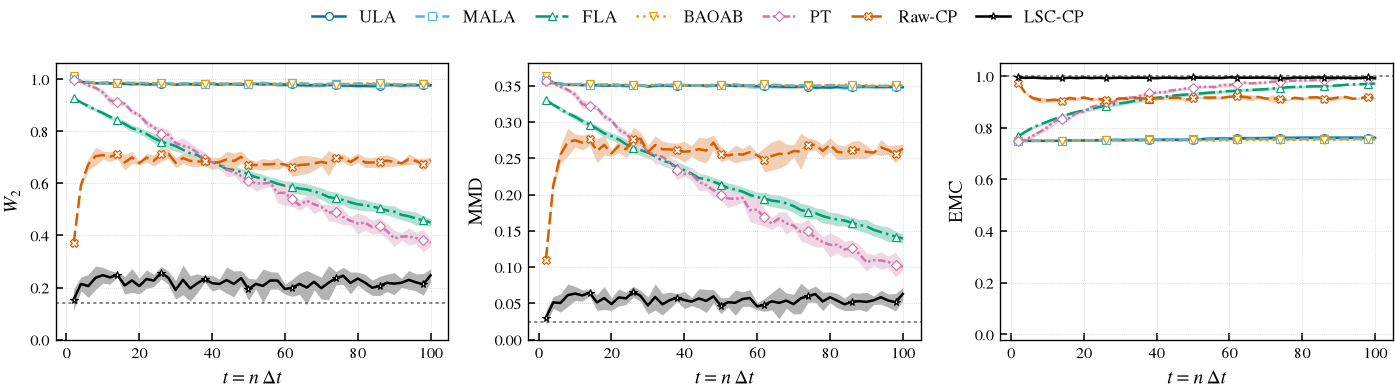

saved: /home/zheyuanlai/levy-sampling/JCP_experiments/figures/coupled_phi4/coupled_phi4_metrics.{png,pdf}


In [8]:
fig = metric_grid(rows, os.path.join(FIGURES, EXPERIMENT + "_metrics"),
                  metrics=("W2", "MMD", "EMC"), floors=floors,
                  emc_target=emc_target)
print("saved:", os.path.join(FIGURES, EXPERIMENT + "_metrics") + ".{png,pdf}")

In [9]:
ts_path = os.path.join(RESULTS, "metrics_timeseries.csv")
write_timeseries_csv(rows, ts_path)
summary_metrics = MAIN_METRICS + ["nonfinite_frac"]
summary = write_summary_csv(rows, C.METHODS, cfg.seeds, summary_metrics,
                            method_info, floors, os.path.join(RESULTS, "summary.csv"))

manifest = dict(
    experiment=EXPERIMENT,
    config=dict(d=cfg.d, N=cfg.n_particles, T=cfg.T, dt0=cfg.dt, dt=dt_final,
                beta=cfg.beta, eps=cfg.eps, lam=cfg.lam, seeds=list(cfg.seeds),
                n_checkpoints=C.N_CHECKPOINTS, warmup_steps=C.N_WARMUP_STEPS,
                batched_seeds=True),
    quadrature=dict(chosen=CHOSEN_QUAD, table=quad_table),
    dt_refinement=[{k: (str(v) if isinstance(v, tuple) else v) for k, v in row.items()}
                   for row in dt_table],
    pt_ladder={k: v for k, v in ladder_info.items()},
    certificate=cert_report,
    bias_floors=floors,
    barrier_verification=barrier_report,
    method_info={m: {k: v for k, v in mi.items() if isinstance(v, (int, float))}
                 for m, mi in method_info.items()},
    hardware=hardware_manifest(),
    pt_phase_mass_crosscheck=pt_crosscheck,
)
write_manifest(os.path.join(RESULTS, "manifest.json"), **manifest)
print("wrote", ts_path)
from IPython.display import display
display(pd.read_csv(os.path.join(RESULTS, "summary.csv")).round(5))

wrote /home/zheyuanlai/levy-sampling/JCP_experiments/results/coupled_phi4/metrics_timeseries.csv


,method,EMC_mean,EMC_std,MMD_mean,MMD_std,TV_mean,TV_std,V_evals_per_step,W2_mean,W2_std,...,jump_count_mean,m_clip_fraction,mala_accept,nonfinite_frac_mean,nonfinite_frac_std,pt_swap_accept,score_quad_evals_per_step,time_to_threshold_TV,wallclock_mean_s,wallclock_std_s
0,ULA,0.76135,0.00932,0.34803,0.00197,0.41589,0.00311,0.0,0.97661,0.00613,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,15.84156,0.0
1,MALA,0.75805,0.00405,0.35047,0.00244,0.41729,0.00152,5000.0,0.98254,0.00490,...,NaN,NaN,0.89110,0.0,0.0,NaN,0.0,inf,41.76765,0.0
2,FLA,0.97160,0.00350,0.13939,0.00639,0.13272,0.01236,0.0,0.45005,0.01411,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,22.20076,0.0
3,BAOAB,0.75536,0.00186,0.35071,0.00224,0.41809,0.00055,0.0,0.98308,0.00518,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,18.86056,0.0
4,PT,0.99169,0.00134,0.10045,0.00509,0.09289,0.00726,30000.0,0.37223,0.01267,...,NaN,NaN,0.87602,0.0,0.0,0.31266,0.0,inf,47.58259,0.0
5,CP,0.91500,0.00310,0.26343,0.00609,0.32851,0.00522,0.0,0.68936,0.01149,...,0.00206,NaN,NaN,0.0,0.0,NaN,0.0,inf,32.46629,0.0
6,LSC-CP,0.99181,0.00210,0.06296,0.00917,0.10251,0.01248,0.0,0.24706,0.02506,...,0.00206,0.0,NaN,0.0,0.0,NaN,3840000.0,inf,104.69291,0.0
